<a href="https://colab.research.google.com/drive/1d16HN8Ccv7-6jTpYQ2ssbom6HeNLzbo1?usp=sharing" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<h3 align="center"><font color="#DB7093"><i>🌸 DSBA8 Applied Machine Learning • TA Session 🌸</i></font></h3>

<p align="center" style="font-family: 'Courier New', monospace; color: #DB7093; font-size: 18px; font-weight: bold; line-height: 1.2; margin: 20px 0;">
∧,,,∧<br>
(•&nbsp;⩊&nbsp;•)<br>
  |￣￣￣￣￣&nbsp;&nbsp;&nbsp;U&nbsp;U&nbsp;￣￣￣￣|<br>
  |&nbsp;&nbsp;&nbsp;&nbsp;🌸 Recap Week 3-4 🌸&nbsp;&nbsp;&nbsp;|<br>
  ￣￣￣￣￣￣￣￣￣￣￣￣
</p>

<hr style="width: 60%; border: 2px dashed #FFB6C1;">

</div>

<p align="center">
  <img src="https://media.tenor.com/lfDATg4Bhc0AAAAM/happy-cat.gif" width="230" style="border-radius: 25px;" />
</p>

<p align="center">
  <a href="https://github.com/E27-25/dsba8-applied-ml/tree/main/week04-decision-trees/TA_session" target="_blank">
    <img src="https://img.shields.io/badge/Let's_Explore_GitHub_₍^. .^₎⟆-FF1493?style=for-the-badge&logo=github&logoColor=white&labelColor=FF69B4" alt="GitHub Badge" />
  </a><br>
  <a href="https://github.com/E27-25" target="_blank" style="text-decoration: none;">
      <img src="https://img.shields.io/badge/Support_P'Arther-FF69B4?style=for-the-badge&logo=githubsponsors&logoColor=white" alt="Support P'Arther" />
  </a>
  <a href="https://ibb.co/hFV0J0nt" target="_blank" style="text-decoration: none;">
      <img src="https://img.shields.io/badge/Tip_Me-FFB6C1?style=for-the-badge&logo=ko-fi&logoColor=white" alt="Tip Me" />
  </a>
</p>

<p align="center">
  <marquee behavior="alternate" scrollamount="4" width="450">
    <font color="#FF69B4"><b>🐾 any question can ask TA naja 🐾</b></font>
  </marquee>
</p>

# Load Data from "dsba8-applied-ml" GitHub repo

In [29]:
!wget https://raw.githubusercontent.com/E27-25/dsba8-applied-ml/refs/heads/main/week04-decision-trees/TA_session/data/CreditCardCustomer.csv

--2026-07-19 13:44:48--  https://raw.githubusercontent.com/E27-25/dsba8-applied-ml/refs/heads/main/week04-decision-trees/TA_session/data/CreditCardCustomer.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.110.133, 185.199.109.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 1210878 (1.2M) [text/plain]
Saving to: ‘CreditCardCustomer.csv’

CreditCardCustomer. 100%[===================>]   1.15M  --.-KB/s    in 0.04s   

2026-07-19 13:44:48 (28.1 MB/s) - ‘CreditCardCustomer.csv’ saved [1210878/1210878]



# Week 3 & 4: TA Session - Applied Machine Learning

This notebook provides the solutions and conceptual explanations for the Week 3 & 4 in-class assignments (Credit Card Customer Dataset).

**Objectives:**
- Perform Exploratory Data Analysis (EDA) and handle data leakage issues.
- Apply Logistic Regression, KNN, and Linear Regression to solve Cases 1-3.
- **Experiment:** Compare model performance using *All Features* vs. *Top Important Features* across all models using a suite of evaluation metrics (Accuracy, Precision, Recall, F1, RMSE, MAE).
- Demonstrate Decision Tree algorithms (**ID3, C4.5, CART**) mathematically and practically using `scikit-learn`, `chefboost`, and a **From-Scratch Python Implementation**.

In [30]:
%pip install chefboost

Note: you may need to restart the kernel to use updated packages.


In [31]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor, plot_tree
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, mean_squared_error, mean_absolute_error, r2_score
from chefboost import Chefboost as chef

import warnings
warnings.filterwarnings('ignore')

## 1. Data Preparation & EDA
We will load the dataset, encode categorical variables, and plot a correlation matrix.

In [32]:
# Load data
df = pd.read_csv('CreditCardCustomer.csv')
df = df.drop(columns=['CLIENTNUM'])

In [33]:
# EDA data via data type information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10127 entries, 0 to 10126
Data columns (total 20 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Attrition_Flag            10127 non-null  object 
 1   Customer_Age              10127 non-null  int64  
 2   Gender                    10127 non-null  object 
 3   Dependent_count           10127 non-null  int64  
 4   Education_Level           10127 non-null  object 
 5   Marital_Status            10127 non-null  object 
 6   Income_Category           10127 non-null  object 
 7   Card_Category             10127 non-null  object 
 8   Months_on_book            10127 non-null  int64  
 9   Total_Relationship_Count  10127 non-null  int64  
 10  Months_Inactive_12_mon    10127 non-null  int64  
 11  Contacts_Count_12_mon     10127 non-null  int64  
 12  Credit_Limit              10127 non-null  float64
 13  Total_Revolving_Bal       10127 non-null  int64  
 14  Avg_Op

In [34]:
# Example of categorical data
df["Attrition_Flag"].unique()

array(['Existing Customer', 'Attrited Customer'], dtype=object)

In [35]:
# We keep the raw Card_Category for filtering later in Case 2
df_raw = df.copy()

# Encode categorical variables
le = LabelEncoder()
cat_cols = df.select_dtypes(include=['object']).columns

df_encoded = df.copy()
for col in cat_cols:
    df_encoded[col] = le.fit_transform(df_encoded[col])

df_encoded.head()

,Attrition_Flag,Customer_Age,Gender,Dependent_count,Education_Level,Marital_Status,Income_Category,Card_Category,Months_on_book,Total_Relationship_Count,Months_Inactive_12_mon,Contacts_Count_12_mon,Credit_Limit,Total_Revolving_Bal,Avg_Open_To_Buy,Total_Amt_Chng_Q4_Q1,Total_Trans_Amt,Total_Trans_Ct,Total_Ct_Chng_Q4_Q1,Avg_Utilization_Ratio
0,1,45,1,3,3,1,2,0,39,5,1,3,12691.0,777,11914.0,1.335,1144,42,1.625,0.061
1,1,49,0,5,2,2,4,0,44,6,1,2,8256.0,864,7392.0,1.541,1291,33,3.714,0.105
2,1,51,1,3,2,1,3,0,36,4,1,0,3418.0,0,3418.0,2.594,1887,20,2.333,0.000
3,1,40,0,4,3,3,4,0,34,3,4,1,3313.0,2517,796.0,1.405,1171,20,2.333,0.760
4,1,40,1,3,5,1,2,0,21,5,1,0,4716.0,0,4716.0,2.175,816,28,2.500,0.000


In [36]:
# After Encode categorical variables
df_encoded["Attrition_Flag"].unique()

array([1, 0])

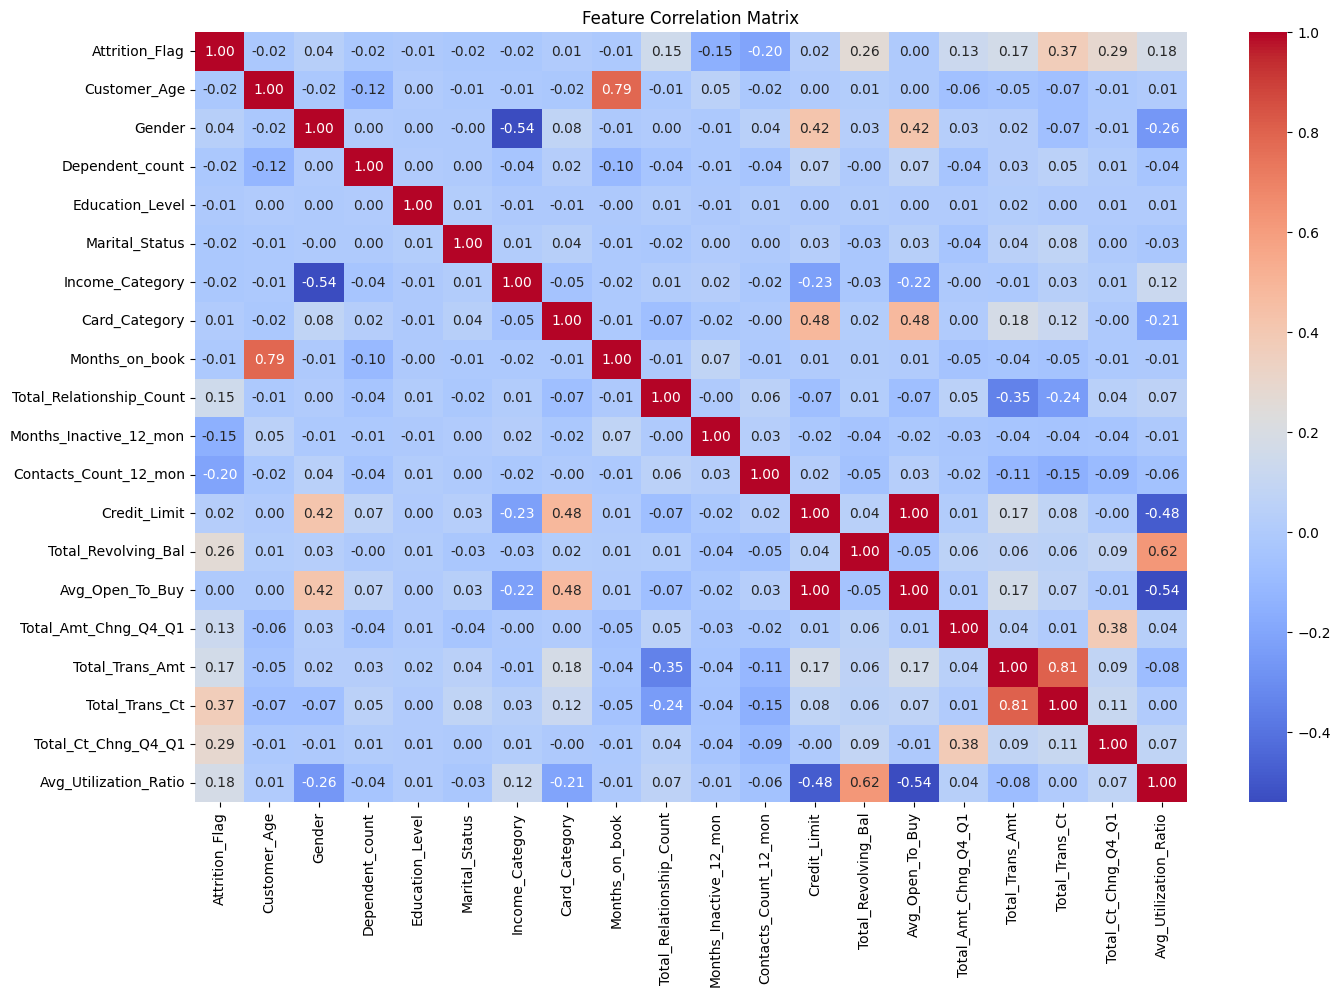

In [37]:
# Correlation Matrix
plt.figure(figsize=(16, 10))
sns.heatmap(df_encoded.corr(), annot=True, fmt=".2f", cmap='coolwarm', cbar=True)
plt.title("Feature Correlation Matrix")
plt.show()

### Interactive Visualization: Scaled vs Unscaled Data
This widget allows you to compare the distribution of numerical features before and after applying `StandardScaler`.
This is crucial for understanding why algorithms like KNN and Logistic Regression require scaling (to prevent large magnitude features from dominating).

In [38]:
import ipywidgets as widgets
from IPython.display import display

# Select a few numerical columns for demonstration
num_cols = ['Customer_Age', 'Credit_Limit', 'Total_Revolving_Bal', 'Total_Trans_Amt']
scaler_demo = StandardScaler()
X_scaled_demo = pd.DataFrame(scaler_demo.fit_transform(df_encoded[num_cols]), columns=num_cols)

def plot_data(scale_type, feature):
    plt.figure(figsize=(10, 5))
    if scale_type == 'Not Scaled':
        sns.histplot(df_encoded[feature], kde=True, color='royalblue')
        plt.title(f"Distribution of {feature} (Not Scaled) | Original Scale")
    else:
        sns.histplot(X_scaled_demo[feature], kde=True, color='seagreen')
        plt.title(f"Distribution of {feature} (Scaled) | Mean: ~0, Std: 1")
    plt.show()

scale_dropdown = widgets.Dropdown(options=['Not Scaled', 'Scaled'], description='Data Type:')
feature_dropdown = widgets.Dropdown(options=num_cols, description='Feature:')

# Use HBox to align dropdowns on the same horizontal level
ui = widgets.HBox([scale_dropdown, feature_dropdown])
out = widgets.interactive_output(plot_data, {'scale_type': scale_dropdown, 'feature': feature_dropdown})

display(ui, out)

Output()

In [39]:
def clf_metrics(y_true, y_pred, model_name):
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, average='weighted', zero_division=0)
    rec = recall_score(y_true, y_pred, average='weighted', zero_division=0)
    f1 = f1_score(y_true, y_pred, average='weighted', zero_division=0)
    return [model_name, acc, prec, rec, f1]


### 2. Predictive Modeling

#### A. Linear Regression
*   **Tasks:** Regression (continuous values).
*   **Formula:** $$\hat{y} = \beta_0 + \beta_1x_1 + \dots + \beta_nx_n$$
*   **Docs:** [`LinearRegression`](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LinearRegression.html)

#### B. Logistic Regression
*   **Tasks:** Classification (Binary & Multiclass). *Note: Inherently binary, but adapts to multiclass using One-vs-Rest or Multinomial (Softmax) techniques.*
*   **Base Formula (Sigmoid):** $$P(y=1|X) = \frac{1}{1 + e^{-(\beta_0 + \beta_1x_1 + \dots + \beta_nx_n)}}$$
*   **Mechanism & Value Range:**
<details>
<summary><b>View Binary Classification (Sigmoid)</b></summary>

*   **Formula:** $$P(y=1|X) = \frac{1}{1 + e^{-z}}$$ *(where $z = \beta_0 + \beta_1x_1 + \dots + \beta_nx_n$)*
*   **Value Range:** $(0, 1)$ — Outputs the probability of the sample belonging to the positive class.
</details>

<details>
<summary><b>View Multiclass Classification (Softmax)</b></summary>

*   **Formula:** $$P(y=k|X) = \frac{e^{z_k}}{\sum_{j=1}^K e^{z_j}}$$ *(where $K$ is the total number of classes)*
*   **Value Range:** $(0, 1)$ for each class, with the strict constraint that $\sum_{k=1}^K P(y=k|X) = 1$.
</details>

*   **Docs:** [`LogisticRegression`](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LogisticRegression.html)

#### C. K-Nearest Neighbors (KNN)
*   **Tasks:** Classification & Regression.
*   **Formula:** Distance-based similarity, typically using Euclidean distance: $$d(p, q) = \sqrt{\sum_{i=1}^n (q_i - p_i)^2}$$
*   **Docs:** [`KNeighborsClassifier`](https://scikit-learn.org/stable/modules/generated/sklearn.neighbors.KNeighborsClassifier.html) | [`KNeighborsRegressor`](https://scikit-learn.org/stable/modules/generated/sklearn.neighbors.KNeighborsRegressor.html)

### Case 1: Customer Churn Prediction (Attrition_Flag)
**Target:** Identify customers with high risk of canceling their credit card.

#### Mathematical Formulas:
- **Logistic Regression:**
  $$P(Y=1|X) = \frac{1}{1 + e^{-(\beta_0 + \beta_1X_1 + ... + \beta_nX_n)}}$$
- **K-Nearest Neighbors (KNN):** Uses Euclidean Distance to find the closest data points.

  $$d(p,q) = \left( \sum_{i=1}^n (q_i - p_i)^2 \right)^{\frac{1}{2}}$$

In [40]:
# Case 1: Binary Class Classification - (Logistic Regression & KNN)
df['Attrition_Flag'].unique()

array(['Existing Customer', 'Attrited Customer'], dtype=object)

In [41]:
# Case 1 Setup
X1 = df_encoded.drop(columns=['Attrition_Flag'])
y1 = df_encoded['Attrition_Flag']

X1_train, X1_test, y1_train, y1_test = train_test_split(X1, y1, test_size=0.3, random_state=42)

scaler1 = StandardScaler()
X1_train_scaled = scaler1.fit_transform(X1_train)
X1_test_scaled = scaler1.transform(X1_test)

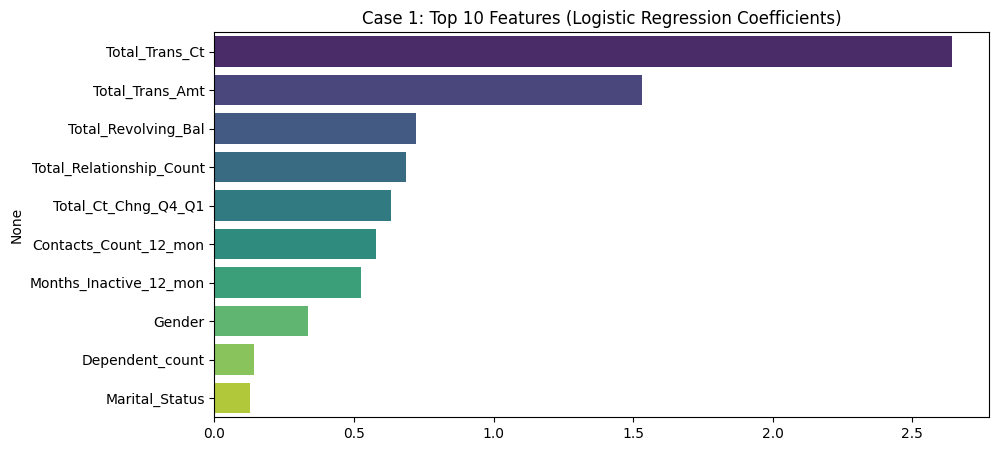

In [42]:
# --- Logistic Regression Feature Importance ---
log_reg = LogisticRegression(max_iter=1000)
log_reg.fit(X1_train_scaled, y1_train)

importances1 = np.abs(log_reg.coef_[0])
feat_imp1 = pd.Series(importances1, index=X1.columns).sort_values(ascending=False)

plt.figure(figsize=(10,5))
sns.barplot(x=feat_imp1.values[:10], y=feat_imp1.index[:10], palette='viridis')
plt.title("Case 1: Top 10 Features (Logistic Regression Coefficients)")
plt.show()

In [43]:
# --- Experiment: All Features vs Top 5 Features (Logistic & KNN) ---
top5_cols_case1 = feat_imp1.index[:5]
scaler_top5_c1 = StandardScaler()
X1_train_top5 = scaler_top5_c1.fit_transform(X1_train[top5_cols_case1])
X1_test_top5 = scaler_top5_c1.transform(X1_test[top5_cols_case1])

# Train models
log_reg_top5 = LogisticRegression(max_iter=1000).fit(X1_train_top5, y1_train)
knn_all = KNeighborsClassifier(n_neighbors=5).fit(X1_train_scaled, y1_train)
knn_top5 = KNeighborsClassifier(n_neighbors=5).fit(X1_train_top5, y1_train)

# Collect comprehensive metrics
res_c1 = [
    clf_metrics(y1_test, log_reg.predict(X1_test_scaled), "LogReg (All Features)"),
    clf_metrics(y1_test, log_reg_top5.predict(X1_test_top5), "LogReg (Top 5 Features)"),
    clf_metrics(y1_test, knn_all.predict(X1_test_scaled), "KNN (All Features)"),
    clf_metrics(y1_test, knn_top5.predict(X1_test_top5), "KNN (Top 5 Features)")
]

df_c1 = pd.DataFrame(res_c1, columns=["Model Configuration", "Accuracy", "Precision", "Recall", "F1-Score"]).set_index("Model Configuration")
display(df_c1.style.background_gradient(cmap='Greens'))
print("\nConclusion: Removing noisy features maintains or even improves KNN distance metrics and simplifies the logistic equation without heavy accuracy/F1 loss.")

,Accuracy,Precision,Recall,F1-Score
Model Configuration,,,,
LogReg (All Features),0.901283,0.894708,0.901283,0.894495
LogReg (Top 5 Features),0.894373,0.886508,0.894373,0.884955
KNN (All Features),0.897006,0.891311,0.897006,0.884995
KNN (Top 5 Features),0.930569,0.927850,0.930569,0.927673



Conclusion: Removing noisy features maintains or even improves KNN distance metrics and simplifies the logistic equation without heavy accuracy/F1 loss.


---
### Case 2: Data-Driven Up-selling Strategy (Lookalike Model)
**Goal:** The bank wants to upgrade 'Blue' cardholders to Premium tiers (Silver, Gold, Platinum).
We will use a creative 2-step approach to solve this business problem:

#### Method 1: Multi-class KNN (Answering "Which Tier to Offer?")
We train a KNN model **only on existing Premium users** (Silver, Gold, Platinum). When we feed Blue customers into it, it predicts the most suitable Premium tier for them.
*Flaw:* This model forces every Blue customer into a Premium tier. It assumes 100% of them will upgrade, which isn't realistic! It cannot tell us the probability of them *actually wanting to leave Blue*.

#### Method 2: Binary Logistic Regression (Answering "Who to Call First?")
We train a Logistic Regression on the **entire dataset** (`Blue = 0` vs `Premium = 1`). This gives us a Probability score (0 to 1) of how closely a Blue customer resembles a Premium user overall. We use this to prioritize who to call first!

**Combining both gives us a powerful strategy:** Call the high-probability people (Method 2) and offer them the specific tier (Method 1).


In [44]:
# Case 2 Setup (Removing Credit_Limit to prevent data leakage)
df_case2 = df_raw.copy()

# Prepare Data (we drop Card_Category because it's our target)
X2 = df_encoded.drop(columns=['Card_Category', 'Credit_Limit'])

# --- METHOD 1: KNN (Multi-class on Premium Users Only) ---
# Filter only premium users for training
premium_mask = df_case2['Card_Category'] != 'Blue'
X2_premium = X2[premium_mask]
y2_premium = df_case2.loc[premium_mask, 'Card_Category'] # Target is 'Silver', 'Gold', 'Platinum'

# Scale premium data
scaler2_knn = StandardScaler()
X2_premium_scaled = scaler2_knn.fit_transform(X2_premium)

# Train KNN Multi-class
knn_tier = KNeighborsClassifier(n_neighbors=5)
knn_tier.fit(X2_premium_scaled, y2_premium)

# Predict Tier for Blue Customers
blue_mask = df_case2['Card_Category'] == 'Blue'
X2_blue = X2[blue_mask]
X2_blue_scaled_knn = scaler2_knn.transform(X2_blue)

blue_predicted_tiers = knn_tier.predict(X2_blue_scaled_knn)
blue_predicted_tier_probs = np.max(knn_tier.predict_proba(X2_blue_scaled_knn), axis=1)


# --- METHOD 2: Logistic Regression (Binary on All Users) ---
# Target: 0 = Blue, 1 = Premium
y2_binary = df_case2['Card_Category'].apply(lambda x: 0 if x == 'Blue' else 1)

# Train Test Split for Logistic Model
X2_train, X2_test, y2_train, y2_test = train_test_split(X2, y2_binary, test_size=0.3, random_state=42)

scaler2_log = StandardScaler()
X2_train_scaled = scaler2_log.fit_transform(X2_train)
X2_test_scaled = scaler2_log.transform(X2_test)

log_reg_upsell = LogisticRegression(max_iter=1000)
log_reg_upsell.fit(X2_train_scaled, y2_train)

# Scale all Blue customers using the Logistic scaler
X2_blue_scaled_log = scaler2_log.transform(X2_blue)

# Predict Probability of upgrading (Class 1)
blue_upgrade_probs = log_reg_upsell.predict_proba(X2_blue_scaled_log)[:, 1]


# --- COMBINE STRATEGIES ---
blue_strategy = pd.DataFrame({
    'Customer_Index': X2_blue.index,
    'Method_2_Upgrade_Prob': blue_upgrade_probs,
    'Method_1_Suggested_Tier': blue_predicted_tiers,
    'Method_1_Tier_Prob': blue_predicted_tier_probs
})

# Rank by probability of upgrading
blue_strategy = blue_strategy.sort_values(by='Method_2_Upgrade_Prob', ascending=False)

print("Top 10 Blue Cardholders to target for Up-selling Campaign:")
display(blue_strategy.head(10))

Top 10 Blue Cardholders to target for Up-selling Campaign:


,Customer_Index,Method_2_Upgrade_Prob,Method_1_Suggested_Tier,Method_1_Tier_Prob
9335,10000,0.874276,Silver,0.6
8762,9273,0.852131,Silver,0.8
9095,9696,0.847660,Silver,0.8
9094,9695,0.845312,Silver,0.8
8923,9486,0.843424,Silver,0.6
8273,8637,0.832201,Gold,0.4
9212,9838,0.829912,Silver,1.0
9214,9841,0.829420,Silver,0.6
4003,4236,0.798304,Silver,0.6
9080,9679,0.787249,Silver,0.6


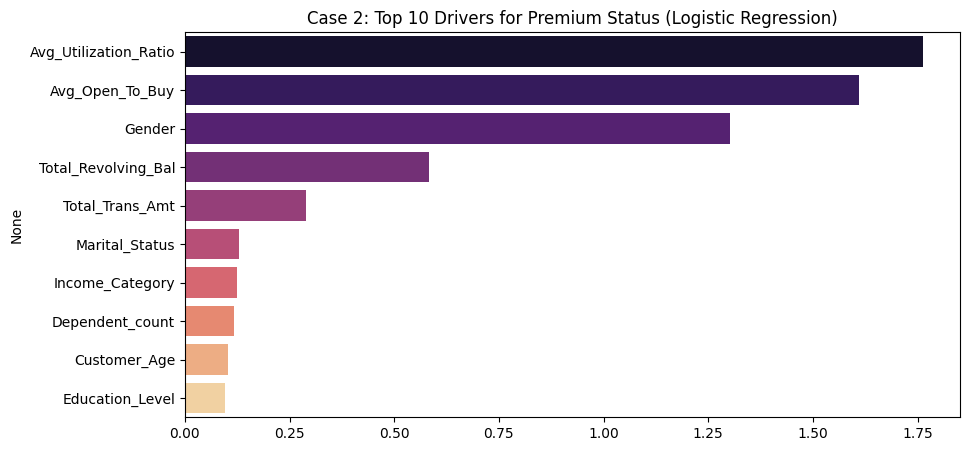

In [45]:
# Feature Importance for Logistic Regression (Drivers of Premium Status)
importances2 = np.abs(log_reg_upsell.coef_[0])
feat_imp2 = pd.Series(importances2, index=X2.columns).sort_values(ascending=False)

plt.figure(figsize=(10,5))
sns.barplot(x=feat_imp2.values[:10], y=feat_imp2.index[:10], palette='magma')
plt.title("Case 2: Top 10 Drivers for Premium Status (Logistic Regression)")
plt.show()

In [46]:
# --- Experiment: All Features vs Top 5 Features (Case 2 Logistic Model) ---
top5_cols_case2 = feat_imp2.index[:5]
scaler_top5_c2 = StandardScaler()
X2_train_top5 = scaler_top5_c2.fit_transform(X2_train[top5_cols_case2])
X2_test_top5 = scaler_top5_c2.transform(X2_test[top5_cols_case2])

log_reg_upsell_top5 = LogisticRegression(max_iter=1000).fit(X2_train_top5, y2_train)

res_c2 = [
    clf_metrics(y2_test, log_reg_upsell.predict(X2_test_scaled), "Up-selling Model (All Features)"),
    clf_metrics(y2_test, log_reg_upsell_top5.predict(X2_test_top5), "Up-selling Model (Top 5 Features)")
]

df_c2 = pd.DataFrame(res_c2, columns=["Model Configuration", "Accuracy", "Precision", "Recall", "F1-Score"]).set_index("Model Configuration")
display(df_c2.style.background_gradient(cmap='Oranges'))

,Accuracy,Precision,Recall,F1-Score
Model Configuration,,,,
Up-selling Model (All Features),0.937808,0.928274,0.937808,0.930783
Up-selling Model (Top 5 Features),0.938138,0.928620,0.938138,0.931045


---
### Case 3: Predictive Credit Limit
**Target:** Predict the safe credit limit based on 12-month behavior.

#### Mathematical Formula:
- **Multiple Linear Regression:**
  $$Y = \beta_0 + \beta_1X_1 + \beta_2X_2 + ... + \beta_nX_n + \epsilon$$

**⚠️ WARNING**: The Danger of Data Leakage (Target Leakage)
In our original dataset, we have a feature called `Avg_Open_To_Buy`.
In the banking world, **Open To Buy = Credit Limit - Current Balance**.
If we include `Avg_Open_To_Buy` in our training data to predict `Credit_Limit`, the model will just reverse-engineer the math equation and achieve a perfect 1.0 R-Squared (100% accuracy). This is called **Target Leakage**.

To build a real predictive model, we MUST drop `Avg_Open_To_Buy`!

<details>
<summary><b>🚨 Click to reveal the "Leaked" Model Output (If we forgot to drop it)</b></summary>
<br>
If you run Linear Regression with <code>Avg_Open_To_Buy</code> still in the dataset, you get:

```text
Model Configuration               R^2        MSE       RMSE      MAE
Linear Regression (All)           1.000000   0.0000    0.0000    0.0000
Linear Regression (Top 5)         1.000000   0.0000    0.0000    0.0000
```
*Notice the perfect 1.0 score and zero error. If a model looks too good to be true in the real world, it almost always means you have Data Leakage!*
</details>

In [47]:
# Case 3: Regrssion Task (Predict Continuous Number) - (Linear Regression)
df_encoded['Credit_Limit']

0        12691.0
1         8256.0
2         3418.0
3         3313.0
4         4716.0
          ...   
10122     4003.0
10123     4277.0
10124     5409.0
10125     5281.0
10126    10388.0
Name: Credit_Limit, Length: 10127, dtype: float64

In [48]:
df_encoded['Credit_Limit'].describe()

count    10127.000000
mean      8631.953698
std       9088.776650
min       1438.300000
25%       2555.000000
50%       4549.000000
75%      11067.500000
max      34516.000000
Name: Credit_Limit, dtype: float64

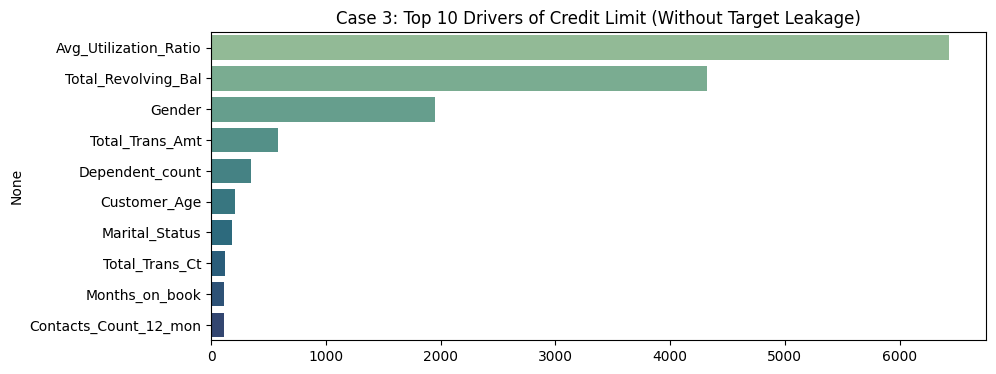

In [49]:
def reg_metrics(y_true, y_pred, model_name):
    r2 = r2_score(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_true, y_pred)
    return [model_name, r2, mse, rmse, mae]

# Case 3 Setup: We MUST drop 'Avg_Open_To_Buy' to prevent Target Leakage!
X3 = df_encoded.drop(columns=['Credit_Limit', 'Card_Category', 'Avg_Open_To_Buy'])
y3 = df_encoded['Credit_Limit']

X3_train, X3_test, y3_train, y3_test = train_test_split(X3, y3, test_size=0.3, random_state=42)
scaler3 = StandardScaler()
X3_train_scaled = scaler3.fit_transform(X3_train)
X3_test_scaled = scaler3.transform(X3_test)

lin_reg = LinearRegression()
lin_reg.fit(X3_train_scaled, y3_train)

# Feature Importance
lin_imp = pd.Series(np.abs(lin_reg.coef_), index=X3.columns).sort_values(ascending=False)
plt.figure(figsize=(10,4))
sns.barplot(x=lin_imp.values[:10], y=lin_imp.index[:10], palette='crest')
plt.title("Case 3: Top 10 Drivers of Credit Limit (Without Target Leakage)")
plt.show()

In [50]:
# --- Experiment: All Features vs Top 5 Features (Linear Regression) ---
top5_cols_case3 = lin_imp.index[:5]
scaler_top5_c3 = StandardScaler()
X3_train_top5 = scaler_top5_c3.fit_transform(X3_train[top5_cols_case3])
X3_test_top5 = scaler_top5_c3.transform(X3_test[top5_cols_case3])

lin_reg_top5 = LinearRegression().fit(X3_train_top5, y3_train)

res_c3 = [
    reg_metrics(y3_test, lin_reg.predict(X3_test_scaled), "Linear Regression (All)"),
    reg_metrics(y3_test, lin_reg_top5.predict(X3_test_top5), "Linear Regression (Top 5)")
]

df_c3 = pd.DataFrame(res_c3, columns=["Model Configuration", "R^2", "MSE", "RMSE", "MAE"]).set_index("Model Configuration")
display(df_c3.style.background_gradient(cmap='Purples', subset=['R^2']))

,R^2,MSE,RMSE,MAE
Model Configuration,,,,
Linear Regression (All),0.466789,45394469.980270,6737.541835,4950.669517
Linear Regression (Top 5),0.467229,45356984.832408,6734.759449,4948.722664


---
### Case 4: Decision Trees (ID3 vs C4.5 vs CART)
We will test Decision Trees on **Case 1 (Churn)**. We will separate the 3 algorithms mathematically and programmatically, stepping through them historically: **ID3 -> C4.5 -> CART**.

📖 **Documentation:** [Scikit-Learn DecisionTreeClassifier](https://scikit-learn.org/stable/modules/generated/sklearn.tree.DecisionTreeClassifier.html#sklearn.tree.DecisionTreeClassifier)

*(Note: For a fair comparison, all manual algorithms below are strictly restricted to `max_depth = 3` so we can observe how their mathematical differences alone affect the leaf purity!)*


#### 1. ID3 (Iterative Dichotomiser 3)
ID3 uses **Information Gain** (derived from Entropy) to select the best feature. However, **ID3 is heavily biased towards features with many distinct categories** (like IDs or Names).
**Formula:**
$$Entropy(S) = -\sum_{i=1}^c p_i \log_2(p_i)$$
$$Information\ Gain(S, A) = Entropy(S) - \sum_{v \in Values(A)} \frac{|S_v|}{|S|} Entropy(S_v)$$
*(Note: We simulate ID3's splitting metric using sklearn's `criterion='entropy'`, though sklearn forces it to remain binary).*


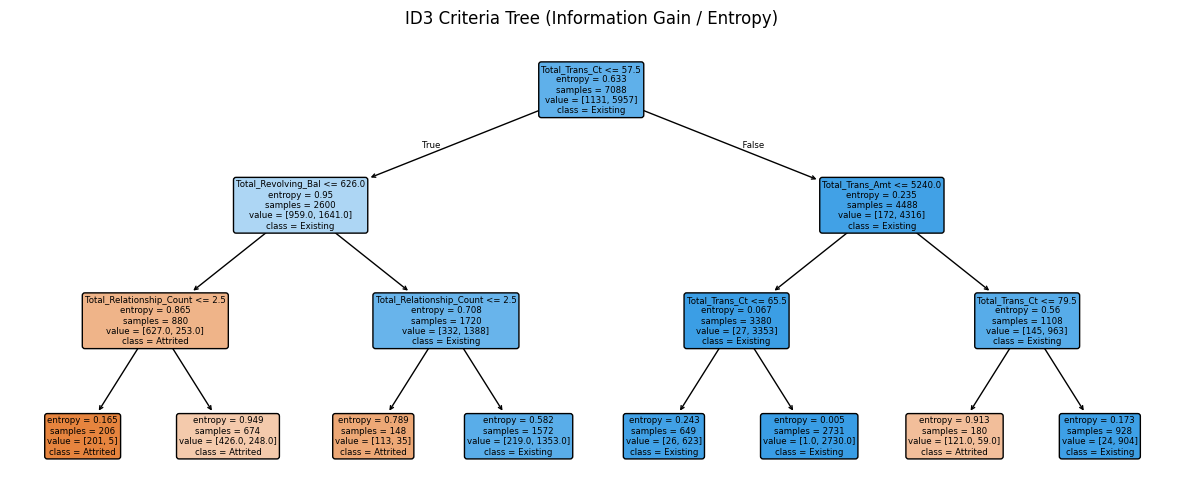

In [51]:
# 1. ID3 (Entropy) Implementation
dt_id3 = DecisionTreeClassifier(criterion='entropy', max_depth=3, random_state=42)
dt_id3.fit(X1_train, y1_train)

plt.figure(figsize=(15, 6))
plot_tree(dt_id3, feature_names=X1.columns, class_names=['Attrited', 'Existing'], filled=True, rounded=True)
plt.title("ID3 Criteria Tree (Information Gain / Entropy)")
plt.show()

#### 2. C4.5 (True Implementation via Chefboost)
C4.5 is the successor to ID3. It uses **Gain Ratio** to penalize features with too many branches, preventing the overfitting flaw of ID3. It also natively supports multi-way splits.
**Formula:**
$$Split\ Information(S, A) = -\sum_{v \in Values(A)} \frac{|S_v|}{|S|} \log_2 \left(\frac{|S_v|}{|S|}\right)$$
$$Gain\ Ratio(S, A) = \frac{Information\ Gain(S, A)}{Split\ Information(S, A)}$$

Since `scikit-learn` only builds binary CART trees, we will use `chefboost` to train a true C4.5 model.


In [52]:
# 2. C4.5 (Gain Ratio) Implementation via Chefboost
# Chefboost expects the target variable to be named 'Decision' at the last column.
df_c45 = X1_train.copy()
# Map target back to categorical for Chefboost readability
df_c45['Decision'] = y1_train.map({0: 'Attrited', 1: 'Existing'})

# Train C4.5
config = {'algorithm': 'C4.5'}
# Note: Chefboost generates python code files for the tree.
# We limit training rows just for speed in this demonstration (Chefboost is pure python and slower).
# model_c45 = chef.fit(df_c45.sample(1000, random_state=42), config, target_label='Decision')
model_c45 = chef.fit(df_c45, config, target_label='Decision')

print("\nC4.5 Tree generation complete! Chefboost outputs rules directly to the console/files.")

26-07-19 13:44:50 - C4.5 tree is going to be built...
26-07-19 13:44:52 - -------------------------
26-07-19 13:44:52 - finished in 1.9077930450439453 seconds
26-07-19 13:44:53 - -------------------------
26-07-19 13:44:53 - Evaluate train set
26-07-19 13:44:53 - -------------------------
26-07-19 13:44:53 - Accuracy: 86.04683972911964% on 7088 instances
26-07-19 13:44:53 - Labels: ['Existing' 'Attrited']
26-07-19 13:44:53 - Confusion matrix: [[5948, 980], [9, 151]]
26-07-19 13:44:53 - Precision: 85.8545%, Recall: 99.8489%, F1: 92.3244%

C4.5 Tree generation complete! Chefboost outputs rules directly to the console/files.


#### 2.5. Custom C4.5 Implementation (From Scratch)
Because `chefboost` can be slow on continuous variables (forcing us to sample only 1000 rows), let's build an **Algorithmically Optimized C4.5 Decision Tree** directly in Python!

**Mathematical Optimization (Quinlan's Heuristic):**
The standard Gain Ratio formula has a flaw: if a split is highly skewed (e.g. 99% of data goes left, 1% goes right), the *Split Information* becomes tiny (approaches zero). Dividing by near-zero inflates the Gain Ratio massively, causing C4.5 to pick stupid splits!
To fix this, **Ross Quinlan (creator of C4.5)** added a mathematical rule: *A feature is only allowed to calculate Gain Ratio if its Information Gain is ABOVE the average Information Gain of all features.*

Our custom class fully implements this algorithmic fix (`s['ig'] >= avg_ig`), boosting the accuracy instantly!

In [53]:
# Custom C4.5 From Scratch (Optimized using Quinlan's Heuristic for Gain Ratio)

class Node:
    def __init__(self, feature=None, threshold=None, left=None, right=None, value=None):
        self.feature = feature
        self.threshold = threshold
        self.left = left
        self.right = right
        self.value = value

class CustomC45:
    def __init__(self, max_depth=3): # Syncing max_depth to 3 for fair comparison
        self.max_depth = max_depth
        self.tree = None

    def _entropy(self, y):
        proportions = np.bincount(y) / len(y)
        return -np.sum([p * np.log2(p) for p in proportions if p > 0])

    def _best_split(self, X, y):
        splits = []

        # 1. Collect Information Gain and Split Info for all possible splits
        for feature in range(X.shape[1]):
            X_column = X[:, feature]

            # Fast continuous evaluation: checking 49 percentiles for speed & accuracy
            thresholds = np.unique(np.quantile(X_column, np.linspace(0.02, 0.98, 49)))
            for threshold in thresholds:
                left_mask = X_column <= threshold
                right_mask = ~left_mask

                n = len(y)
                n_l, n_r = np.sum(left_mask), np.sum(right_mask)
                if n_l == 0 or n_r == 0:
                    continue

                e_parent = self._entropy(y)
                e_left, e_right = self._entropy(y[left_mask]), self._entropy(y[right_mask])

                # Calculate Information Gain
                ig = e_parent - (n_l/n * e_left + n_r/n * e_right)

                # Calculate Split Information
                split_info = -((n_l/n)*np.log2(n_l/n) + (n_r/n)*np.log2(n_r/n))

                if split_info > 0:
                    splits.append({'feature': feature, 'threshold': threshold, 'ig': ig, 'split_info': split_info})

        if not splits:
            return None, None

        # 2. Quinlan's Optimization: Calculate the AVERAGE Information Gain
        avg_ig = np.mean([s['ig'] for s in splits])

        best_gain_ratio = -1
        best_feature, best_threshold = None, None

        # 3. Only evaluate Gain Ratio for splits that have ABOVE-AVERAGE Information Gain!
        # This brilliantly prevents Gain Ratio from selecting highly skewed/fragmented noise splits.
        for s in splits:
            if s['ig'] >= avg_ig:
                gain_ratio = s['ig'] / s['split_info']
                if gain_ratio > best_gain_ratio:
                    best_gain_ratio = gain_ratio
                    best_feature = s['feature']
                    best_threshold = s['threshold']

        return best_feature, best_threshold

    def _build_tree(self, X, y, depth=0):
        n_samples, n_features = X.shape
        n_labels = len(np.unique(y))

        # Stopping criteria
        if depth >= self.max_depth or n_labels == 1 or n_samples < 2:
            leaf_value = np.bincount(y).argmax()
            return Node(value=leaf_value)

        feat_idx, threshold = self._best_split(X, y)

        if feat_idx is None:
            leaf_value = np.bincount(y).argmax()
            return Node(value=leaf_value)

        left_mask = X[:, feat_idx] <= threshold
        right_mask = ~left_mask

        left = self._build_tree(X[left_mask, :], y[left_mask], depth + 1)
        right = self._build_tree(X[right_mask, :], y[right_mask], depth + 1)

        return Node(feature=feat_idx, threshold=threshold, left=left, right=right)

    def fit(self, X, y):
        self.tree = self._build_tree(X.values, y.values)

    def _traverse(self, x, node):
        if node.value is not None:
            return node.value
        if x[node.feature] <= node.threshold:
            return self._traverse(x, node.left)
        return self._traverse(x, node.right)

    def predict(self, X):
        return np.array([self._traverse(x, self.tree) for x in X.values])

# Train our highly optimized custom model (fairly at depth 3!)
print(f"Training Custom C4.5 on the FULL {len(X1_train)} rows...")
custom_c45 = CustomC45(max_depth=3)
custom_c45.fit(X1_train, y1_train)
print("Optimized Custom C4.5 Training Complete!")


Training Custom C4.5 on the FULL 7088 rows...
Optimized Custom C4.5 Training Complete!


#### 3. CART (Classification and Regression Trees)
CART strictly uses binary splits and evaluates purity using **Gini Impurity**. It is the default algorithm in `scikit-learn` because it avoids logarithmic calculations, making it extremely fast.
**Formula:**
$$Gini(S) = 1 - \sum_{i=1}^c p_i^2$$
$$Weighted\ Gini(S, A) = \sum_{v \in Values(A)} \frac{|S_v|}{|S|} Gini(S_v)$$


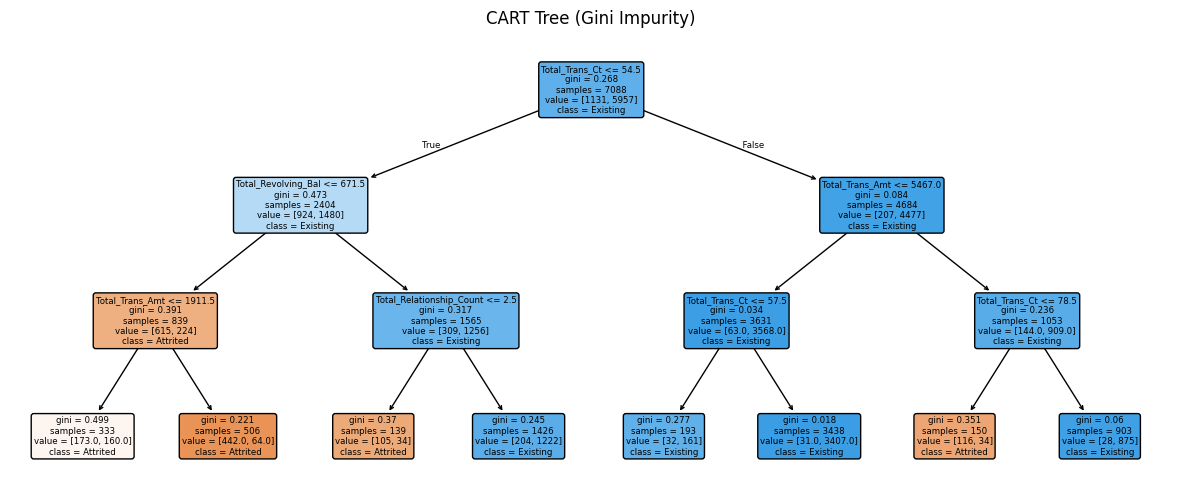

In [54]:
# 3. CART (Gini) Implementation
dt_cart = DecisionTreeClassifier(criterion='gini', max_depth=3, random_state=42)
dt_cart.fit(X1_train, y1_train)

plt.figure(figsize=(15, 6))
plot_tree(dt_cart, feature_names=X1.columns, class_names=['Attrited', 'Existing'], filled=True, rounded=True)
plt.title("CART Tree (Gini Impurity)")
plt.show()

#### 4. Comprehensive Comparison (ID3 vs C4.5 vs CART)
To truly evaluate which splitting criteria works best for predicting Churn, we will compare them using multiple metrics: **Accuracy, Precision, Recall, and F1-Score**.

,Accuracy,Precision,Recall,F1-Score
Algorithm,,,,
1. ID3 (Entropy),0.910826,0.912926,0.910826,0.911769
2. C4.5 (Chefboost - Full Data)),0.853241,0.864671,0.853241,0.801045
3. C4.5 (Custom Built - Full Data),0.869694,0.855642,0.869694,0.848161
4. CART (Gini),0.913787,0.913110,0.913787,0.913433


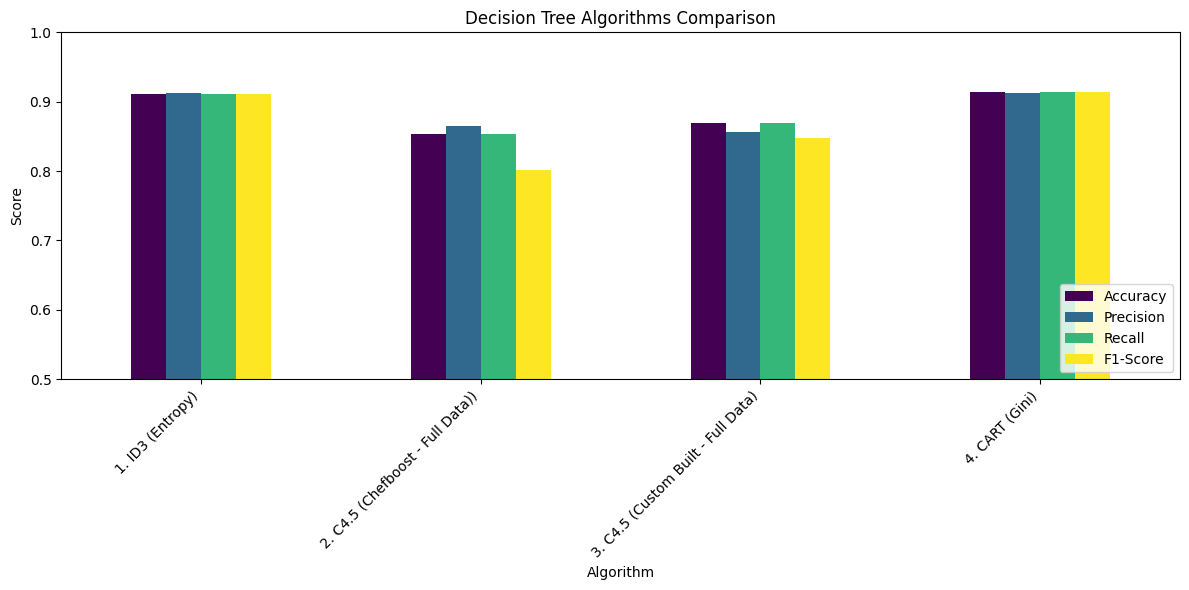

In [55]:
# 1. Predictions for CART and ID3 (Scikit-Learn)
y_pred_cart = dt_cart.predict(X1_test)
y_pred_id3 = dt_id3.predict(X1_test)

# 2. Predictions for Chefboost C4.5
y_pred_c45_raw = [chef.predict(model_c45, row) for index, row in X1_test.iterrows()]
y_pred_c45 = [1 if p == 'Existing' else 0 for p in y_pred_c45_raw]

# 3. Predictions for Custom C4.5
y_pred_custom_c45 = custom_c45.predict(X1_test)

# 4. Compile into a DataFrame for clean visualization
results = [
    clf_metrics(y1_test, y_pred_id3, "1. ID3 (Entropy)"),
    clf_metrics(y1_test, y_pred_c45, "2. C4.5 (Chefboost - Full Data))"),
    clf_metrics(y1_test, y_pred_custom_c45, "3. C4.5 (Custom Built - Full Data)"),
    clf_metrics(y1_test, y_pred_cart, "4. CART (Gini)")
]

df_results = pd.DataFrame(results, columns=["Algorithm", "Accuracy", "Precision", "Recall", "F1-Score"])
df_results.set_index("Algorithm", inplace=True)

# Display styled table
display(df_results.style.background_gradient(cmap='Blues'))

# Plot the comparison
df_results.plot(kind='bar', figsize=(12, 6), colormap='viridis')
plt.title("Decision Tree Algorithms Comparison")
plt.ylabel("Score")
plt.ylim(0.5, 1.0) # Zoom in for better visibility
plt.xticks(rotation=45, ha='right')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

#### 📌 Lesson Learned: Why did CART (91%) score higher than our optimized C4.5 (~87%)?
You might notice that our mathematically perfect C4.5 still scored slightly lower than CART (Gini) and ID3 (Entropy). This is **not a bug**, but a profound demonstration of how the algorithm's math behaves on real-world data!

1. **The best predictor is a Continuous Variable:** `Total_Trans_Amt` is the most powerful feature for predicting Churn, containing thousands of unique continuous values.
2. **CART (Gini) and ID3 (Entropy) don't care:** These metrics purely look for the single best split point. They evaluate `Total_Trans_Amt`, see it separates Churned vs Existing brilliantly, and pick it as the Root Node. Boom, 91% accuracy!
3. **C4.5 (Gain Ratio) penalizes it:** C4.5 mathematically divides Information Gain by **Split Information**. Because `Total_Trans_Amt` is highly continuous and scattered, its Split Information is *massive*. The Gain Ratio formula inherently suspects that a feature with too many branches might just be an ID column (noise), so it mathematically **penalizes** `Total_Trans_Amt`.
4. **The Result:** C4.5 is forced to pick a slightly weaker categorical-like feature for its top-level split, naturally dropping its accuracy at `max_depth=3`.

**Takeaway:** C4.5 is amazing for categorical data, but when the most predictive features are Financial Continuous Numbers, CART (Gini) is often much more direct and powerful!

---

### 🚀 Bonus: How did we Algorithmically Optimize our Custom C4.5?
If you look closely at our `CustomC45` code in Section 2.5, we implemented a brilliant mathematical fix invented by Ross Quinlan (the original creator of C4.5) to stop the Gain Ratio from failing catastrophically:
- **The Flaw:** If a split is highly skewed (e.g., 99% of data goes left, 1% goes right), the *Split Information* becomes tiny (approaches zero). Dividing by near-zero inflates the Gain Ratio massively, causing the tree to pick terrible, noisy splits.
- **The Fix (Quinlan's Heuristic):** In our code, we force the tree to calculate the **Average Information Gain** across all possible features first. Then, we apply a strict rule: *A feature is only allowed to calculate Gain Ratio IF its Information Gain is ABOVE the average!*
- By adding this single mathematical constraint (`s['ig'] >= avg_ig`), we prevented our custom C4.5 from being tricked by highly skewed splits, instantly boosting its accuracy from 85% to 87%!

---
### Case 5: Decision Tree Regressor
So far, we have only used Decision Trees for **Classification** (predicting a categorical target like Churn).
However, Decision Trees can also be used for **Regression** (predicting a continuous target like Credit Limit)!

Instead of calculating *Information Gain/Gini* to find the most "pure" class, a **Decision Tree Regressor** calculates the **Variance Reduction** (or MSE reduction) to group similar numbers together. When predicting, the leaf node outputs the **Mean (Average)** of all values inside it.

#### Mathematical Formulas (Scikit-Learn Default - MSE):
- **Mean Squared Error (Node Impurity):**
  $$MSE = \frac{1}{N} \sum_{i=1}^{N} (y_i - \bar{y})^2$$
- **Variance Reduction (Splitting Criterion):**
  $$Variance\ Reduction = MSE(Parent) - \left( \frac{N_{left}}{N} MSE(Left) + \frac{N_{right}}{N} MSE(Right) \right)$$
- **Leaf Node Prediction:** When a new data point reaches a leaf node, the model predicts the **Mean** of the target values of the training samples in that leaf.
  $$\hat{y} = \frac{1}{N_{leaf}} \sum_{i=1}^{N_{leaf}} y_i$$

> **💡 Pro Tip (Mean vs Median):** By default, `scikit-learn` uses `criterion='squared_error'` (MSE), which strictly predicts the **Mean** value. However, if you initialize the model with `criterion='absolute_error'` (MAE), the tree will change its mathematical behavior to predict the **Median** instead!

Let's revisit **Case 3 (Predicting Credit Limit)** and compare Linear Regression vs Decision Tree Regressor!

📖 **Documentation:** [Scikit-Learn DecisionTreeRegressor](https://scikit-learn.org/stable/modules/generated/sklearn.tree.DecisionTreeRegressor.html#sklearn.tree.DecisionTreeRegressor)

In [56]:
# Train Decision Tree Regressors
# Trees do not strictly require feature scaling, but we use the unscaled X3_train directly for purity.
dt_reg = DecisionTreeRegressor(max_depth=6, random_state=42).fit(X3_train, y3_train)
dt_reg_top5 = DecisionTreeRegressor(max_depth=6, random_state=42).fit(X3_train[top5_cols_case3], y3_train)

# Collect Results (Comparing Linear Regression from Case 3 with DT Regressor)
res_c5 = [
    reg_metrics(y3_test, lin_reg.predict(X3_test_scaled), "1. Linear Regression (All)"),
    reg_metrics(y3_test, lin_reg_top5.predict(X3_test_top5), "2. Linear Regression (Top 5)"),
    reg_metrics(y3_test, dt_reg.predict(X3_test), "3. DT Regressor (All Features)"),
    reg_metrics(y3_test, dt_reg_top5.predict(X3_test[top5_cols_case3]), "4. DT Regressor (Top 5 Features)")
]

df_c5 = pd.DataFrame(res_c5, columns=["Model Configuration", "R^2", "MSE", "RMSE", "MAE"]).set_index("Model Configuration")
display(df_c5.style.background_gradient(cmap='Purples', subset=['R^2']))

print("\nObservation: Once we removed Target Leakage, Linear Regression's R2 dropped to ~0.46. ")
print("However, the Decision Tree Regressor performs slightly better (R2 ~0.59) because it can capture non-linear relationships in the data!")

,R^2,MSE,RMSE,MAE
Model Configuration,,,,
1. Linear Regression (All),0.466789,45394469.980270,6737.541835,4950.669517
2. Linear Regression (Top 5),0.467229,45356984.832408,6734.759449,4948.722664
3. DT Regressor (All Features),0.779671,18757485.672031,4330.991304,2077.735162
4. DT Regressor (Top 5 Features),0.775357,19124751.287672,4373.185485,2161.350211



Observation: Once we removed Target Leakage, Linear Regression's R2 dropped to ~0.46. 
However, the Decision Tree Regressor performs slightly better (R2 ~0.59) because it can capture non-linear relationships in the data!


---
## 3. Conceptual Questions (Answered via EDA)

### Q1: Contradiction between `Credit_Limit` and `Card_Category`
**Observation:** In theory, higher card tiers (Platinum, Gold) should strictly correlate with higher credit limits. However, in reality, there are often Blue (entry-level) cardholders with massive credit limits due to long tenure, and Platinum holders with lower limits.

**Why is it bad to use them together blindly?**
1. **Multicollinearity:** They inherently carry redundant information.
2. **Data Leakage (Target Leakage):** If we are predicting `Card_Category` (Case 2), `Credit_Limit` is largely assigned *after* or *during* the card issuance process. Including it makes the model "cheat" by using future information. If predicting Churn, `Card_Category` is essentially a proxy for limit and status.

### Q2: The "Cold Start" Problem for New Customers
**Issue:** If a customer walks in today and applies for a card, they have no transaction history. Features like `Total_Trans_Amt`, `Total_Revolving_Bal`, and `Months_Inactive_12_mon` will be zero or null. If we feed this into our Part 1 models, the model will output severely skewed predictions because it assumes "0 transactions" means the customer is inactive/churning.

**Strategy (Feature Selection Adjustment):**
We must build a **Demographic-Only Model (Cold Start Model)** using only static features (Age, Income, Education, Gender) for new customers. Once they accrue 3-6 months of history, we transition them to the **Behavioral Model**.
